In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

file_path = "C:/Users/Super/PycharmProjects/MSiD/resources/student_mental_health_burnout.csv"

df = pd.read_csv(file_path, )

# Testing and checking for invalid data
print("First 5 records:", df.head())

print(df.info())

pd.set_option('display.max_columns', None)
print(df.describe())

First 5 records:    student_id  age  gender course year  daily_study_hours  daily_sleep_hours  \
0      100001   23    Male  BTech  1st                4.3                6.8   
1      100002   20    Male  BTech  3rd                1.4                4.7   
2      100003   24  Female    BCA  4th                3.7                4.8   
3      100004   21    Male    BSc  4th                1.6                6.7   
4      100005   23   Other    BSc  4th                2.0                6.7   

   screen_time_hours stress_level  anxiety_score  depression_score  \
0                6.1         High             10                 3   
1                3.0         High              2                10   
2                1.5          Low              2                 7   
3                7.0         High              3                 3   
4                5.4         High              7                 7   

   academic_pressure_score  financial_stress_score  social_support_score  \
0    

Text(0, 0.5, 'Liczność')

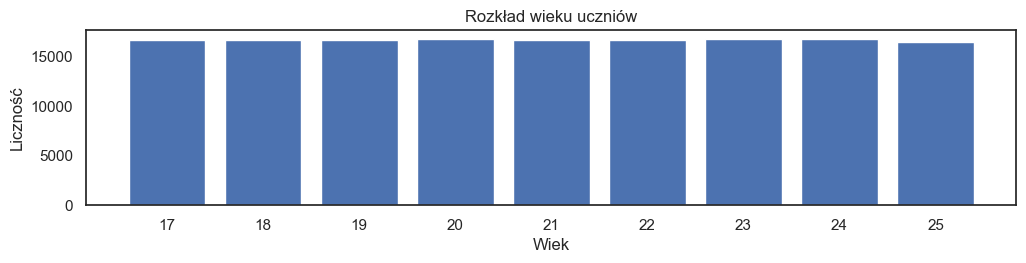

In [2]:
# Visualization
sns.set_theme(style="white")
plt.figure(figsize=(12, 5))

age_plot = plt.subplot(2, 1, 1)
age_plot.bar(df['age'].unique(), df['age'].value_counts())
plt.xticks(ticks=df['age'].unique())
# sns.catplot(df['age'].dropna(), color='skyblue')
plt.title('Rozkład wieku uczniów')
plt.xlabel('Wiek')
plt.ylabel('Liczność')

In [ ]:
fig = plt.figure(figsize=(18, 6))
gs = GridSpec(1, 3, figure=fig, wspace=0.35)

w = 0.25

ax3 = fig.add_subplot(gs[1])
burnout_year = df.groupby(['year','burnout_level']).size().unstack(fill_value=0)
order = ['1st','2nd','3rd','4th']
burnout_year = burnout_year.reindex(order)
burnout_year_pct = burnout_year.div(burnout_year.sum(axis=1), axis=0) * 100
x = np.arange(len(burnout_year_pct))
for i, level in enumerate(['Low','Medium','High']):
    ax3.bar(x + i*w, burnout_year_pct[level], w, label=level, alpha=0.9, edgecolor='none')
ax3.set_xticks(x + w)
ax3.set_xticklabels(order)
ax3.set_ylabel('Percentage (%)')
ax3.set_title('Burnout by Year', color='#c0c0d8', pad=10)
ax3.legend(framealpha=0.2, fontsize=9)
ax3.grid(axis='y', alpha=0.3)
ax3.spines[['top','right','left','bottom']].set_visible(False)

In [ ]:
fig1 = plt.figure(figsize=(18, 6))
gs = GridSpec(2, 3, figure=fig1, wspace=0.35)

fig1.add_subplot(gs[0])


In [ ]:
# Histogram: X = czas przed ekranem, Y = sredni poziom wypalenia
screen_col = "screen_time" if "screen_time" in df.columns else "screen_time_hours"

plot_df = df[[screen_col, "burnout_level"]].dropna().copy()
burnout_to_num = {"Low": 1, "Medium": 2, "High": 3}
plot_df["burnout_num"] = plot_df["burnout_level"].map(burnout_to_num)
plot_df = plot_df.dropna(subset=["burnout_num"])

# Tworzymy przedzialy godzin i liczmy sredni burnout w kazdym przedziale
bins = np.histogram_bin_edges(plot_df[screen_col], bins=12)
plot_df["screen_bin"] = pd.cut(plot_df[screen_col], bins=bins, include_lowest=True)
mean_by_bin = plot_df.groupby("screen_bin", observed=True)["burnout_num"].mean()

bin_centers = [interval.mid for interval in mean_by_bin.index]
bin_widths = [interval.length for interval in mean_by_bin.index]

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))
plt.bar(
    bin_centers,
    mean_by_bin.values,
    width=bin_widths,
    color="#66c2a5",
    edgecolor="white",
    align="center",
)

plt.ylim(1, 3)
plt.yticks([1, 2, 3], ["Low (1)", "Medium (2)", "High (3)"])
plt.xlabel("Liczba godzin przed ekranem [h/day]")
plt.ylabel("Sredni poziom wypalenia")
plt.title("Histogram: sredni poziom wypalenia vs czas przed ekranem")
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Uporządkowanie zmiennej docelowej (aby na wykresach zachować logiczną kolejność)
burnout_order = ['Low', 'Medium', 'High']
df['burnout_level'] = pd.Categorical(df['burnout_level'], categories=burnout_order, ordered=True)

# 3. Lista naszych "najbardziej obiecujących" cech numerycznych
top_numeric_features = [
    'depression_score',
    'academic_pressure_score',
    'daily_sleep_hours',
    'social_support_score'
]

# 4. Konfiguracja i rysowanie wykresów
# Tworzymy siatkę 2x2 dla 4 wykresów
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
sns.set_theme(style="whitegrid")

# Pętla rysująca boxploty
for i, feature in enumerate(top_numeric_features):
    row = i // 2
    col = i % 2

    # Rysowanie boxplota
    sns.boxplot(
        data=df,
        x='burnout_level',
        y=feature,
        ax=axes[row, col],
        palette={'Low': '#2ecc71', 'Medium': '#f1c40f', 'High': '#e74c3c'} # Kolory dla czytelności
    )

    # Dodanie tytułów i etykiet
    axes[row, col].set_title(f'Rozkład {feature} w zależności od poziomu wypalenia', fontsize=12, pad=10)
    axes[row, col].set_xlabel('Poziom Wypalenia (Burnout Level)', fontsize=10)
    axes[row, col].set_ylabel(feature, fontsize=10)

# Dopasowanie odstępów i wyświetlenie
plt.tight_layout()
plt.show()

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Zamiana zmiennej docelowej na liczby, żeby sprawdzić korelację (0=Low, 1=Medium, 2=High)
burnout_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df['burnout_numeric'] = df['burnout_level'].map(burnout_mapping)

# Wybranie tylko kolumn numerycznych
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Obliczenie korelacji z naszą nową zmienną docelową
correlations = numeric_df.corr()['burnout_numeric'].sort_values(ascending=False)
print(correlations)

burnout_numeric            1.000000
academic_pressure_score    0.003649
student_id                 0.002077
financial_stress_score     0.001067
depression_score           0.000985
daily_study_hours          0.000270
physical_activity_hours   -0.000436
cgpa                      -0.000613
social_support_score      -0.000818
age                       -0.001565
anxiety_score             -0.002011
attendance_percentage     -0.002262
screen_time_hours         -0.003048
daily_sleep_hours         -0.003356
Name: burnout_numeric, dtype: float64
